# Regression
### Jimmy Azar

We'll explore linear regression and the quality of regression. We'll also apply a nonlinear regression method, namely kernel regression.

## Linear Regression

We consider simple linear regression which consists of fitting a linear function to the data. The main assumption here is that the data comes from a linear model given by:

$$y = \beta_0 + \beta_1 x + \epsilon$$

Thereafter, we try to estimate the model with the regression line:

$$\widehat{y} = \beta_0 + \beta_1 x$$

The parameters are usually estimated using the least squares method which minimizes the sum of squares difference between the estimated values and the actual observed data $[y_1,y_2,...,y_n]$:

$$J_{LS} = \sum_i \epsilon_i^2 = \sum_i (y_i -\beta_0-\beta_1 x_i)^2$$

The parameter estimates may be obtained analytically by setting the partial derivatives with respect to the offset and the other coefficients of the above equation to zero and solving to arrive at:

$$\widehat{\beta} = (\textbf{X}^T \textbf{X})^{-1} \textbf{X}^T \textbf{y} $$

where $\textbf{X} = \pmatrix{
x_1 & 1 \\
x_2 & 1 \\
. & . \\
. & . \\
x_n & 1 \\
}$, $\textbf{y} = \pmatrix{
y_1 \\
y_2 \\
. \\
. \\
y_n
}$, and $\widehat{\beta} = \pmatrix{
\beta_1 \\
\beta_0 
}$

We'll write a function named **linear_regression()** to solve the above equation.

In [1]:
def linear_regression(X, y):
    X = np.stack([X,np.ones(X.shape[0])],axis=1)
    beta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return beta

(a). We generate a random training dataset consisting of 25 data points as follows:

- Generate 25 input objects distributed uniformly on $[0,1]$
- Select values for the coefficients. Let $\beta_0 = 2$ and $\beta_1 = -1$.
- Generate the output values following the equation: $y = \beta_0 + \beta_1 x$
- Add Gaussian noise with zero mean and standard deviation $\sigma = 0.1$.

Finally, we plot the data.

(b). Then, we use **linear_regression()** to find the least-squares estimates denoted by $\widehat{\beta}_0$ and $\widehat{\beta}_1$ (the inputs are arrays). We plot the estimated regression curve superimposed along with a plot of the observed data.

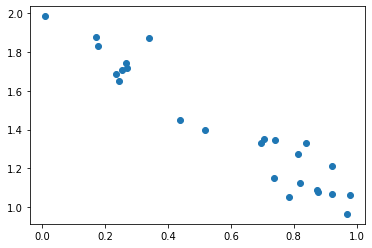

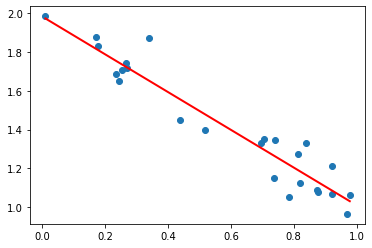

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# part (a)
def linear_regression(X, y):
    X = np.stack([X,np.ones(X.shape[0])],axis=1)
    beta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return beta

beta1, beta0 = -1, 2
sigma = 0.1

X = np.random.uniform(low=0,high=1,size=25)
noise = np.random.normal(loc=0,scale=sigma,size=25)
y = beta0 + beta1*X + noise

plt.scatter(X,y)
plt.show()

# part (b)
beta1_pred, beta0_pred = linear_regression(X,y)

X_test = np.sort(X)
y_pred = beta0_pred + beta1_pred*X_test

plt.scatter(X,y)
plt.plot(X_test,y_pred,c='r',linewidth=2)
plt.show()

Notably, Python's scipy and sklearn have their own methods for fitting a linear regression model.

In [3]:
# scipy
from scipy.stats import linregress
beta1_pred, beta0_pred, _, _, _ = linregress(X, y)

# sklearn
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X.reshape(-1,1), y)
beta1_pred, beta0_pred = model.coef_, model.intercept_
y_pred = model.predict(X_test.reshape(-1,1))

Next, we generate datasets of sizes $[5,10,20,50,100]$. We repeat this 10 times in a for loop and save the parameter estimates $\widehat{\beta}_0$ and $\widehat{\beta}_1$. Then, we create an errorbar plot of the mean and standard deviation of these estimates.

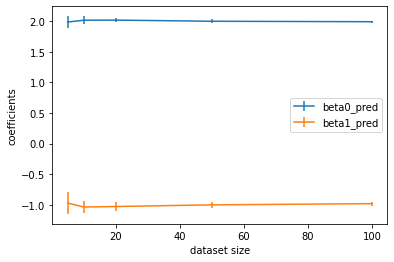

In [4]:
size = [5,10,20,50,100]
b0_mean, b1_mean, b0_std, b1_std = ([] for i in range(4))

for i in size:
    b1, b0 = [], []
    for j in range(10):
        X = np.random.uniform(low=0, high=1, size=i)
        noise = np.random.normal(loc=0, scale=1, size=i)*sigma
        y = beta0 + beta1*X + noise
        beta1_pred, beta0_pred = linear_regression(X, y)
        b1.append(beta1_pred)
        b0.append(beta0_pred)
    b0_mean.append(np.mean(b0))
    b1_mean.append(np.mean(b1))
    b0_std.append(np.std(b0))
    b1_std.append(np.std(b1))

plt.errorbar(size, b0_mean, b0_std, label='beta0_pred')
plt.errorbar(size, b1_mean, b1_std, label='beta1_pred')
plt.xlabel('dataset size')
plt.ylabel('coefficients')
plt.legend()
plt.show()

## Regression Quality  

Using the identity: 

$$ y_i - \widehat{y}_i =  (y_i - \overline{y}_i) - (\widehat{y}_i - \overline{y}_i)$$
we can derive: 

$$\sum_i  (y_i - \overline{y}_i)^2 = \sum_i  (\widehat{y}_i - \overline{y}_i)^2 + \sum_i  (y_i - \widehat{y}_i)^2 $$
We can then assess the quality of regression by evaluating the ratio $R^2$ consisting of dividing the first *RHS* term in the above equation by the *LHS* term. A ratio close to 1 is indicative of a linear trend or non-zero slope in the data.   

We generate a dataset consisting of 25 objects, with $\sigma = 0.1$, $\beta_0 = 2$, and $\beta_1 = -1$. Then, we compute the coefficient estimates and the ratio $R^2$(`*`).

Next, we set $\beta_1$ to vary beteen -1 and 1 in equally-spaced steps, and generate as many datasets. We then, estimate the regression coefficients for each dataset. We repeat this 10 times and create an errorbar plot of $R^2$ versus $\beta_1$.

In [5]:
# scipy 
from scipy.stats import linregress
beta1_pred, beta0_pred, r_value, p_value, std_err = linregress(X, y)
R_sq = r_value**2

# scikit-learn 
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X.reshape(-1,1), y)
beta1_pred = model.coef_
beta0_pred = model.intercept_
y_pred = model.predict(X_test.reshape(-1,1))
R_sq = model.score(X.reshape(-1,1), y)
print(R_sq)

0.8831501607352634


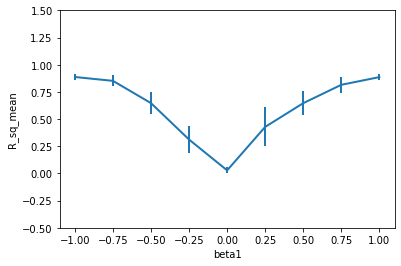

In [6]:
coef = np.linspace(-1,1,9)
R_sq_mean, R_sq_std = [], []

for beta1 in coef:
    R_sq =[]
    for j in range(10):
        X = np.random.uniform(low=0,high=1,size=25)
        noise = np.random.normal(loc=0,scale=sigma,size=25)
        y = beta0 + beta1*X + noise
        
        beta1_pred, beta0_pred, r_value, p_value, std_err = linregress(X, y)
        R_sq.append(r_value**2)
    
    R_sq_mean.append(np.mean(R_sq))
    R_sq_std.append(np.std(R_sq))

plt.errorbar(coef, R_sq_mean, R_sq_std, linewidth=2)
plt.xlabel('beta1')
plt.ylabel('R_sq_mean')
plt.ylim([-0.5,1.5])
plt.show()

## Nonlinear Regression

We'll explore kernel regression as a form of local weighted regression.

First, we implement the function **kernel_regression()** which takes as input the training set abscissa values `X_train` and ordinate values `y_train`, a test set `X_test`, and kernel width `h`. The output of the function is a set of regression predictions `y_pred`. For every test object or query point `q`, **kernel_regression()** gives a kernel-smoothed output by weighing training set objects with a kernel function `K()` as follows: 

$$\widehat{y}(q) = \dfrac{\sum_i K \left( \dfrac{x_i-q}{h} \right) y_i}{\sum_i K \left( \dfrac{x_i-q}{h} \right)}$$

The kernel function employed by **kernel_regression()** is a Gaussian kernel with width `h` representing the standard deviation.

In [7]:
# 1D case
def kernel_regression(X_train, y_train, X_test, h):
    y_pred = []
    for i in range(len(X_test)):
        K = np.exp(-(X_train-X_test[i])**2/h**2)
        y_pred.append((K*y_train).sum()/np.sum(K)) 
    return y_pred

Using the function **synth_data()**, we generate a training dataset with $n=50$ objects and noise level $\sigma=0.1$.

In [8]:
def synth_data(n_samples, sigma):
    X = np.random.uniform(low=0,high=1,size=n_samples)
    y = np.sin(4*X) + np.random.normal(loc=0,scale=sigma,size=n_samples) 
    return X, y 

Then, we plot the data and generate a test set: **X_test = np.arange(0,1,0.01)**. We use the function **kernel_regression()** with kernel width $h=0.1$ to compute the predictions for the test set. Finally, we plot these using a different color onto the same figure.

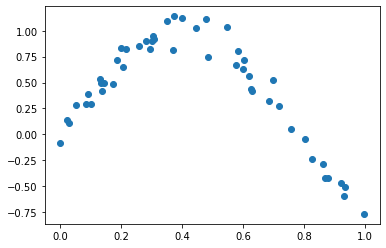

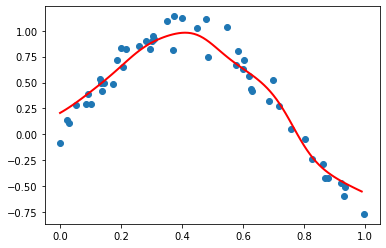

In [9]:
X_train, y_train = synth_data(n_samples=50, sigma=0.1)

plt.scatter(X_train, y_train)
plt.show()

X_test, h = np.arange(0,1,0.01), 0.1
y_test = kernel_regression(X_train, y_train, X_test, h)

plt.scatter(X_train, y_train)
plt.plot(X_test, y_test, c='r', linewidth=2)
plt.show() 

So far, we were able to generate a test set. However, in practice, we often have only a single dataset to work with. Furthermore, we need to obtain a suitable value for the kernel width $h$ in an objective manner using only the given dataset. Therefore, we should split the dataset into a training set and a validation set, and then train our kernel regression model using the training set and see how it performs on the validation set. We finally repeat the process several times for randomly drawn training sets and validation sets and for different values of $h$. The optimal value of $h$ is that which yields the lowest validation error. The function **optimize_h()** performs all these steps. We specify a range of kernel widths, $h = [0.01, 0.05, 0.1, 0.2, 0.3]$. The output will be an errorbar plot using the mean and standard deviation values of the mean square error (MSE) as a function of kernel width $h$.

In [10]:
def optimize_h(X, y, h):
    from sklearn.model_selection import train_test_split
    rep = 5
    mse = np.zeros([rep,len(h)])
    for j, bandwidth in enumerate(h):
        for i in range(5):
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
            y_pred = kernel_regression(X_train, y_train, X_test, bandwidth)
            mse[i,j] = ((y_pred - y_test)**2).mean() 
    plt.errorbar(h, mse.mean(axis=0), mse.std(axis=0), linewidth=2)
    plt.xlabel('h')
    plt.ylabel('mse')
    plt.show()

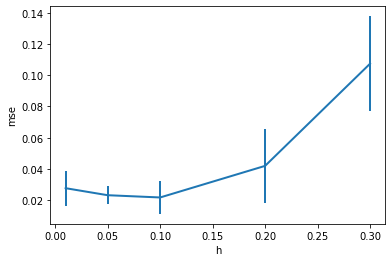

In [11]:
def optimize_h(X, y, h):
    
    from sklearn.model_selection import train_test_split
    
    rep = 5
    mse = np.zeros([rep,len(h)])
    for j, bandwidth in enumerate(h):
        for i in range(5):
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
            y_pred = kernel_regression(X_train, y_train, X_test, bandwidth)
            mse[i,j] = ((y_pred - y_test)**2).mean() 
    plt.errorbar(h, mse.mean(axis=0), mse.std(axis=0), linewidth=2)
    plt.xlabel('h')
    plt.ylabel('mse')
    plt.show()
    
X_train, y_train = synth_data(n_samples=50, sigma=0.1)

optimize_h(X_train, y_train, [0.01,0.05,0.1,0.2,0.3])

## Ridge regression

Next, we explore ridge regression and observe how coefficients shrink when increasing the regularization parameter.

We load the data from the file 'prostate.txt' which consists of 8 predictor variables and a target variable (antigen level). The last column indicates which data points should be included in the training set. We compute the correlation matrix using the full dataset, without including the last (indicator) column. We visualize the matrix using a heatmap.

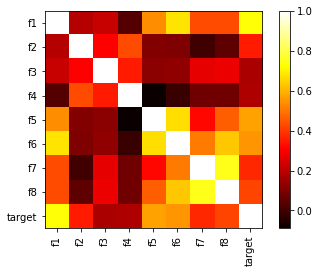

In [12]:
path_to_file = '../data/prostate.txt'
data = pd.read_csv(path_to_file, sep=' ')

corrmat = data.drop(['training_set'],axis=1).corr().round(2)

plt.xticks(ticks=np.arange(len(data.columns)-1),labels=data.columns[:-1],rotation=90)
plt.yticks(ticks=np.arange(len(data.columns)-1),labels=data.columns[:-1])
plt.imshow(corrmat,cmap='hot')
plt.colorbar()
plt.show()

We'll apply ridge regression on the prostate dataset. Recall that coefficients are given by the following closed-form solution:

$$\widehat{{\beta}}_{ridge} = (\textbf{X}^T \textbf{X} + \lambda \textbf{I})^{-1} \textbf{X}^T \textbf{y}$$

These coefficients do not include the offset $\widehat{\beta}_0$ which can be computed as the mean of the target variable $\textbf{y}$. To apply the above equation, $\textbf{X}$ should consist of the training set with 8 features, i.e. the dimensions of matrix $\textbf{X}$ are $67 \times 8$. Moreover, before applying the equation, $\textbf{X}$ should be normalized by subtracting the mean and dividing by the standard deviation for each feature. The target variable $\textbf{y}$ should only have its mean subtracted. 

We select a range of values for the penalty term $\lambda$ as follows: $\lambda = [0.1,1,10,20,50,100,200,500,1000,2000,5000,10000]$. Looping over the values of $\lambda$, we solve for the 8 coefficients for each value of $\lambda$. Finally, we generate a plot showing how these coefficients shrink to zero as $\lambda$ increases. Notably, we use the `log10` of $\lambda$ on the x-axis.

In [13]:
path_to_file = '../data/prostate.txt'
data = pd.read_csv(path_to_file, sep=' ')

X = data[data['training_set']==1].drop(['target','training_set'],axis=1)
y = data[data['training_set']==1]['target']

X = (X - X.mean())/X.std()

In [14]:
n, p = X.shape
L = [0.1,1,10,20,50,100,200,500,1000,2000,5000,10000]

list_beta = [np.linalg.inv(X.T.dot(X) + np.identity(p)*l).dot(X.T).dot(y-y.mean()) for l in L]
beta = np.array(list_beta)

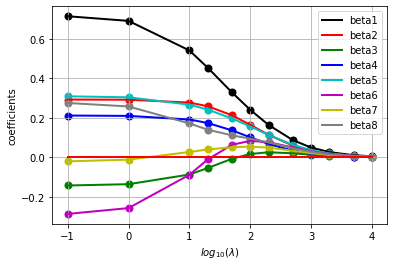

In [15]:
# create plot
colors = ['k','r','g','b','c','m','y','gray']

for i in range(p): 
    plt.plot(np.log10(L),beta[:,i],c=colors[i],linewidth=2,label='beta'+str(i+1))
    plt.scatter(np.log10(L),beta[:,i],c=colors[i],linewidth=2)

plt.plot(np.log10(L),np.zeros(len(L)),c='red',linewidth=2) #add x-axis
plt.xlabel('$log_{10}(\lambda$)') 
plt.ylabel('coefficients')
plt.legend()
plt.grid()
plt.show()

An alternative to plotting the coefficients as a function of $\lambda$ in a line plot, we can generate a heatmap revealing the same information.

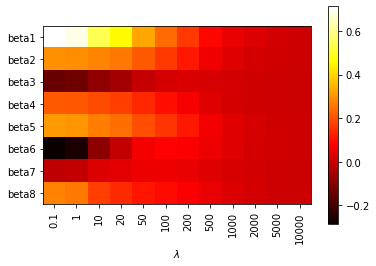

In [16]:
plt.xticks(ticks=range(len(L)), labels=L, rotation=90)
plt.yticks(ticks=range(p), labels=['beta'+str(i+1) for i in range(p)])
plt.imshow(beta.T,cmap='hot') #(8, 12)
plt.colorbar()
plt.xlabel('$\lambda$')
plt.show()